<div align='center'>
<h1>Analisis Perbandingan Fuzzy Mamdani dan Sugeno</h1>
<h3>dalam Sistem Rekomendasi Restoran</h3>
<br>
<b>Dataset:</b> <a href='https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data'>Zomato Restaurants Data</a>
</div>

##### Identitas Kelompok
##### Mata Kuliah : Dasar Kecerdasan Artificial

## 1. Import Library

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import os

# path ke root folder project
sys.path.insert(0, os.path.abspath('.'))

from fuzzy.membership import (fuzzify_all, mf_output, get_mf_curves,
                               trapezoid, triangle, SUGENO_CONSTANTS,
                               BP_COST, BP_VOTES)
from fuzzy.mamdani import (mamdani_predict, mamdani_batch, evaluate_rules,
                            aggregate, centroid, RULES, get_rekomendasi_level)
from fuzzy.sugeno  import sugeno_predict, sugeno_batch, weighted_average

print('Semua modul from scratch berhasil diimport.')

Semua modul from scratch berhasil diimport.


## 2. Load Dataset

In [4]:
df = pd.read_csv('zomato.csv', encoding='latin-1')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,Botswana Pula(P),No,No,No,No,3,4.4,Green,Very Good,336
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.0,Green,Very Good,520
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979333,14.540000,"Seafood, Filipino, Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.2,Green,Very Good,677
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.9,Dark Green,Excellent,621
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.056532,14.572041,Filipino,...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,532


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [5]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 3. Exploratory Data Analysis (EDA)

In [6]:
# cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per kolom:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Total missing: 9


In [9]:
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 0


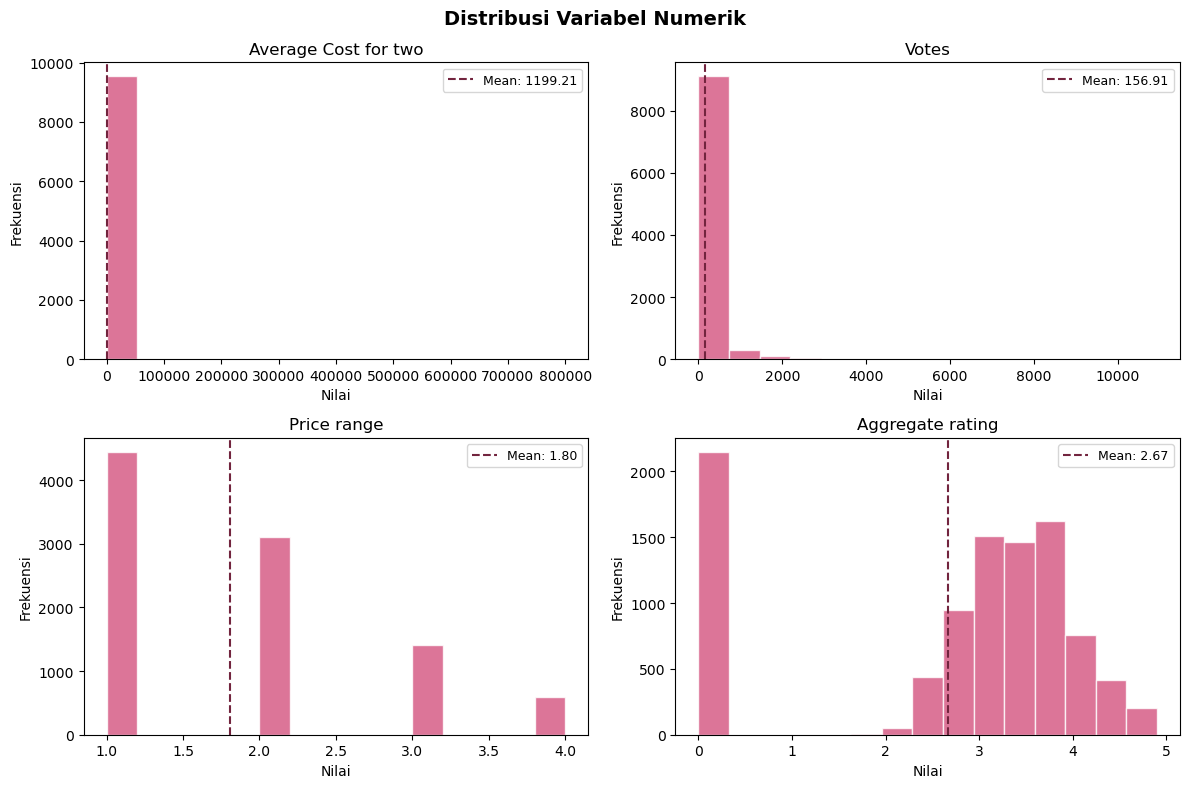

In [10]:
# distribusi kolom numerik — histogram
num_cols = ['Average Cost for two', 'Votes', 'Price range', 'Aggregate rating']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i // 2][i % 2]
    ax.hist(df[col].dropna(), bins=15, color='#D4537E', alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.axvline(df[col].mean(), color='#72243E', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

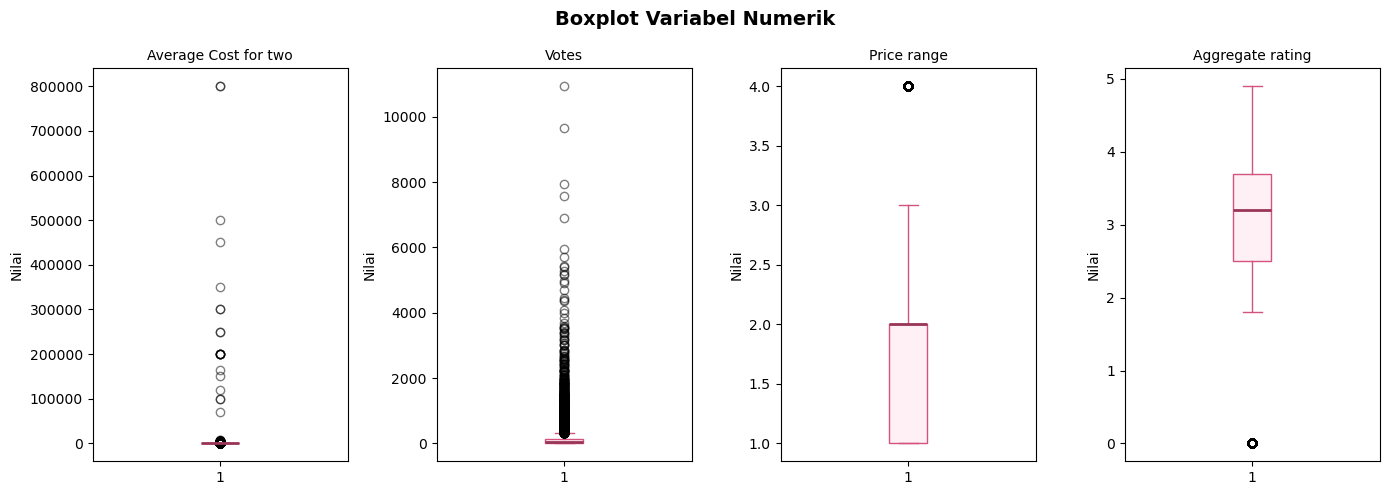

In [11]:
# boxplot untuk cek outlier
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
fig.suptitle('Boxplot Variabel Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#FFF0F5', color='#D4537E'),
                    medianprops=dict(color='#993556', linewidth=2),
                    whiskerprops=dict(color='#D4537E'),
                    capprops=dict(color='#D4537E'),
                    flierprops=dict(marker='o', color='#D4537E', alpha=0.5))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

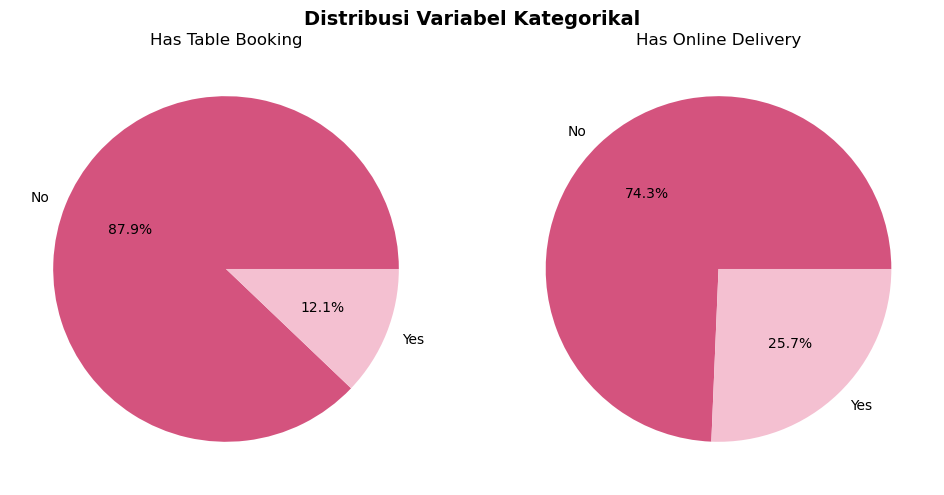

In [12]:
# distribusi kolom kategorikal — pie chart
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')

tb_counts = df['Has Table booking'].value_counts()
axes[0].pie(tb_counts.values, labels=tb_counts.index, autopct='%1.1f%%',
            colors=['#D4537E', '#F4C0D1'])
axes[0].set_title('Has Table Booking')

od_counts = df['Has Online delivery'].value_counts()
axes[1].pie(od_counts.values, labels=od_counts.index, autopct='%1.1f%%',
            colors=['#D4537E', '#F4C0D1'])
axes[1].set_title('Has Online Delivery')

plt.tight_layout()
plt.show()

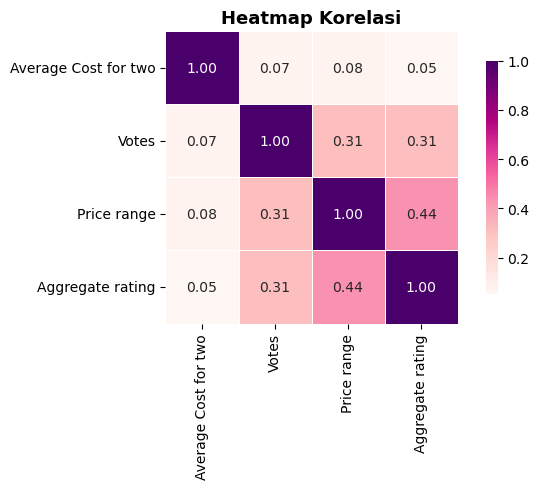

In [13]:
# heatmap korelasi
df_corr = df[['Average Cost for two', 'Votes', 'Price range', 'Aggregate rating']].copy()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdPu',
            ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

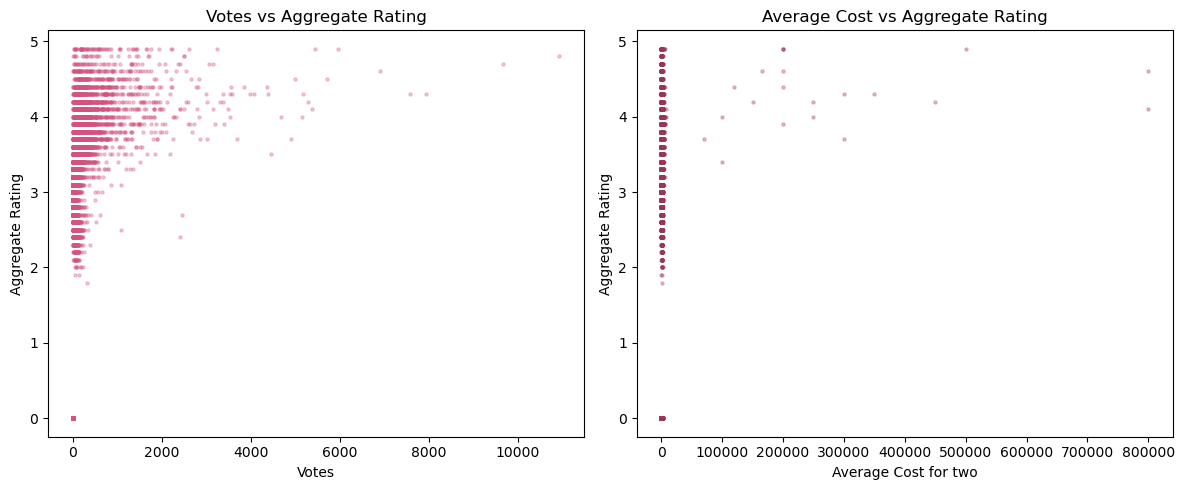

In [14]:
# scatter plot votes vs aggregate rating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Votes'], df['Aggregate rating'],
                alpha=0.3, color='#D4537E', s=5)
axes[0].set_xlabel('Votes')
axes[0].set_ylabel('Aggregate Rating')
axes[0].set_title('Votes vs Aggregate Rating')

axes[1].scatter(df['Average Cost for two'], df['Aggregate rating'],
                alpha=0.3, color='#993556', s=5)
axes[1].set_xlabel('Average Cost for two')
axes[1].set_ylabel('Aggregate Rating')
axes[1].set_title('Average Cost vs Aggregate Rating')

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [16]:
cols = ['Restaurant Name', 'Average Cost for two', 'Price range',
        'Votes', 'Has Table booking', 'Has Online delivery', 'Aggregate rating']
data = df[cols].copy()

# Filter rating 0 & encode Yes/No
data = data[data['Aggregate rating'] > 0]
data['Has Table booking']   = data['Has Table booking'].map({'Yes': 1, 'No': 0})
data['Has Online delivery'] = data['Has Online delivery'].map({'Yes': 1, 'No': 0})
data = data.dropna().reset_index(drop=True)

print(f'Shape setelah preprocessing: {data.shape}')
print(f'Missing values: {data.isnull().sum().sum()}')
data.head()

Shape setelah preprocessing: (7403, 7)
Missing values: 0


,Restaurant Name,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Aggregate rating
0,Le Petit Souffle,1100,3,314,1,0,4.8
1,Izakaya Kikufuji,1200,3,591,1,0,4.5
2,Heat - Edsa Shangri-La,4000,4,270,1,0,4.4
3,Ooma,1500,4,365,0,0,4.9
4,Sambo Kojin,1500,4,229,1,0,4.8


## 5. Membership Function

Fungsi keanggotaan diimplementasikan **from scratch** tanpa library fuzzy.  
Menggunakan dua tipe fungsi: `trapezoid` dan `triangle`.  
Breakpoint ditentukan secara **adaptif** dari distribusi data (kuartil p25, p50, p75).

In [17]:
print('Breakpoint Harga (Average Cost for two):')
for k, v in BP_COST.items():
    print(f'  {k}: {v}')
print()
print('Breakpoint Votes:')
for k, v in BP_VOTES.items():
    print(f'  {k}: {v}')

Breakpoint Harga (Average Cost for two):
  min: 0.0
  p25: 300.0
  p50: 500.0
  p75: 800.0
  max: 800000.0

Breakpoint Votes:
  min: 4.0
  p25: 19.0
  p50: 60.0
  p75: 181.0
  max: 10934.0


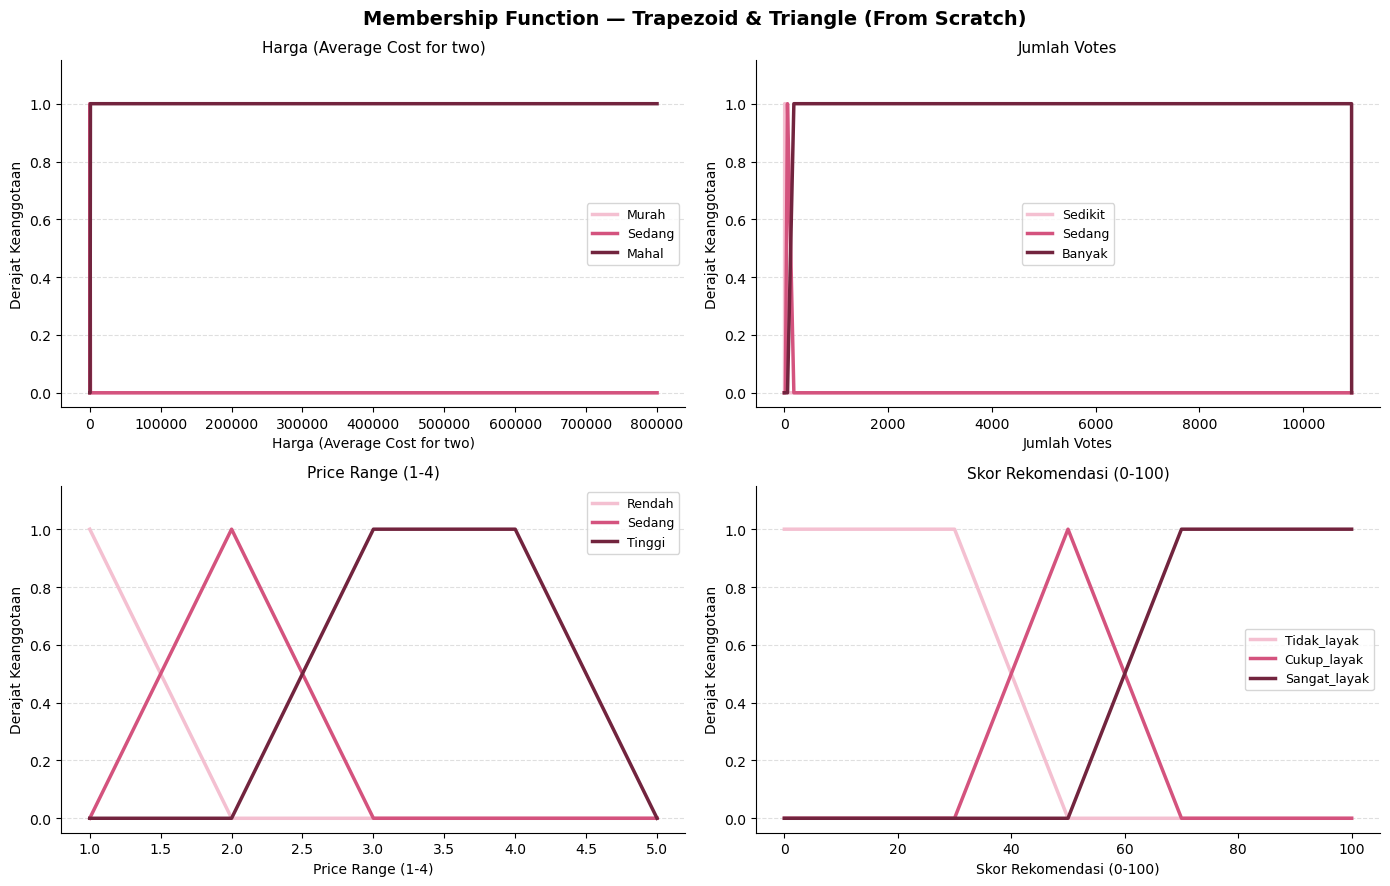

In [19]:
# visualisasi fungsi keanggotaan semua variabel
curves = get_mf_curves()

labels_map = {
    'harga'      : (['murah', 'sedang', 'mahal'],           'Harga (Average Cost for two)'),
    'votes'      : (['sedikit', 'sedang', 'banyak'],        'Jumlah Votes'),
    'price_range': (['rendah', 'sedang', 'tinggi'],         'Price Range (1-4)'),
    'output'     : (['tidak_layak', 'cukup_layak', 'sangat_layak'], 'Skor Rekomendasi (0-100)'),
}

colors = ['#F4C0D1', '#D4537E', '#72243E', '#993556']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Membership Function — Trapezoid & Triangle (From Scratch)', fontsize=14, fontweight='bold')

for idx, (key, (labels, title)) in enumerate(labels_map.items()):
    ax = axes[idx // 2][idx % 2]
    cv = curves[key]
    for i, lbl in enumerate(labels):
        ax.plot(cv['x'], cv[lbl], color=colors[i], linewidth=2.5, label=lbl.capitalize())
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(cv['xlabel'])
    ax.set_ylabel('Derajat Keanggotaan')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Rule Base (17 Rules)

In [20]:
print(f"{'No':<4} {'Kondisi':<60} {'Output'}")
print('-' * 80)
for i, rule in enumerate(RULES):
    conds = ' AND '.join([f'{var}={lbl}' for var, lbl in rule['conditions']])
    print(f"{i+1:<4} {conds:<60} {rule['output']}")

No   Kondisi                                                      Output
--------------------------------------------------------------------------------
1    harga=murah AND votes=banyak                                 sangat_layak
2    harga=murah AND votes=sedang                                 cukup_layak
3    harga=murah AND votes=sedikit                                cukup_layak
4    harga=sedang AND votes=banyak                                sangat_layak
5    harga=sedang AND votes=sedang                                cukup_layak
6    harga=sedang AND votes=sedikit                               tidak_layak
7    harga=mahal AND votes=banyak                                 cukup_layak
8    harga=mahal AND votes=sedang                                 tidak_layak
9    harga=mahal AND votes=sedikit                                tidak_layak
10   price=rendah AND votes=banyak                                sangat_layak
11   price=tinggi AND votes=sedikit                            

## 7. Demo Fuzzifikasi

In [21]:
# contoh input restoran
harga       = 500.0
votes       = 200.0
price_range = 2
booking     = 1      # 1 = Ya
delivery    = 1      # 1 = Ya

fuzz = fuzzify_all(harga, votes, price_range, booking, delivery)

print('Hasil fuzzifikasi:')
print(f'  Harga          : {fuzz["harga"]}')
print(f'  Votes          : {fuzz["votes"]}')
print(f'  Price Range    : {fuzz["price"]}')
print(f'  Booking        : {fuzz["booking"]}')
print(f'  Delivery       : {fuzz["delivery"]}')

Hasil fuzzifikasi:
  Harga          : {'murah': 0.0, 'sedang': 1.0, 'mahal': 0.0}
  Votes          : {'sedikit': 0.0, 'sedang': 0.0, 'banyak': 1.0}
  Price Range    : {'rendah': 0.0, 'sedang': 1.0, 'tinggi': 0.0}
  Booking        : {'tidak': 0.0, 'ya': 1.0}
  Delivery       : {'tidak': 0.0, 'ya': 1.0}


## 8. Fuzzy Mamdani

Alur: **Fuzzifikasi → Inferensi (AND=min, agregasi=max) → Defuzzifikasi (Centroid)**

In [22]:
result_m = mamdani_predict(harga, votes, price_range, booking, delivery)

print(f'Skor Rekomendasi : {result_m["score"]}')
print(f'Level            : {result_m["level"]}')
print(f'Rule aktif       : {len(result_m["fired_rules"])} dari 17')
print(f'Runtime          : {result_m["runtime"]}s')
print()
print('Rule yang aktif:')
for r in result_m['fired_rules']:
    conds = ' AND '.join([f'{v}={l}' for v, l in r['conditions']])
    print(f'  Rule {r["rule_idx"]:>2}: {conds} → {r["output"]} (α={r["firing_strength"]})')

Skor Rekomendasi : 79.8395
Level            : SANGAT LAYAK
Rule aktif       : 2 dari 17
Runtime          : 0.00052s

Rule yang aktif:
  Rule  4: harga=sedang AND votes=banyak → sangat_layak (α=1.0)
  Rule 13: booking=ya AND delivery=ya → sangat_layak (α=1.0)


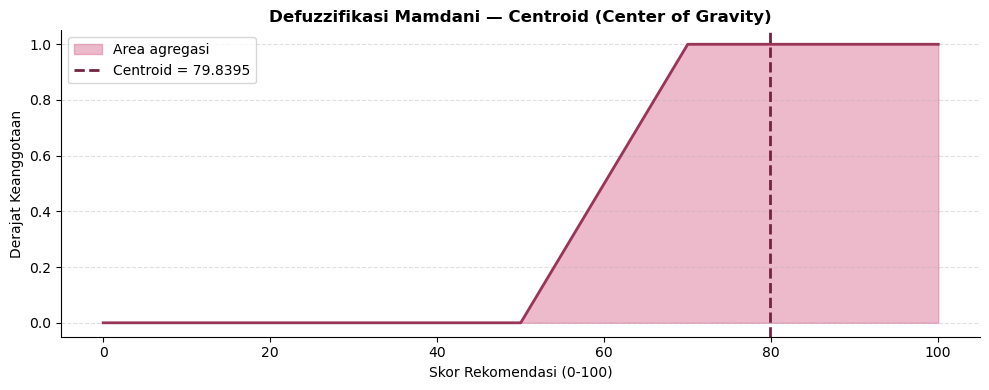

In [23]:
# visualisasi agregasi Mamdani
fig, ax = plt.subplots(figsize=(10, 4))

x_vals = result_m['x_values']
agg    = result_m['aggregated']

ax.fill_between(x_vals, agg, alpha=0.4, color='#D4537E', label='Area agregasi')
ax.plot(x_vals, agg, color='#993556', linewidth=2)
ax.axvline(result_m['score'], color='#72243E', linestyle='--', linewidth=2,
           label=f'Centroid = {result_m["score"]}')
ax.set_title('Defuzzifikasi Mamdani — Centroid (Center of Gravity)', fontweight='bold')
ax.set_xlabel('Skor Rekomendasi (0-100)')
ax.set_ylabel('Derajat Keanggotaan')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Fuzzy Sugeno

Alur: **Fuzzifikasi → Inferensi (AND=min) → Defuzzifikasi (Weighted Average)**  
Output setiap rule adalah konstanta: tidak_layak=20, cukup_layak=50, sangat_layak=85

In [24]:
result_s = sugeno_predict(harga, votes, price_range, booking, delivery)

print(f'Skor Rekomendasi : {result_s["score"]}')
print(f'Level            : {result_s["level"]}')
print(f'Rule aktif       : {len(result_s["fired_rules"])} dari 17')
print(f'Runtime          : {result_s["runtime"]}s')
print()
print('Rule yang aktif:')
for r in result_s['fired_rules']:
    conds = ' AND '.join([f'{v}={l}' for v, l in r['conditions']])
    print(f'  Rule {r["rule_idx"]:>2}: {conds} → {r["output"]} (α={r["firing_strength"]}, z={r["output_value"]})')

Skor Rekomendasi : 85.0
Level            : SANGAT LAYAK
Rule aktif       : 2 dari 17
Runtime          : 0.00033s

Rule yang aktif:
  Rule  4: harga=sedang AND votes=banyak → sangat_layak (α=1.0, z=85)
  Rule 13: booking=ya AND delivery=ya → sangat_layak (α=1.0, z=85)


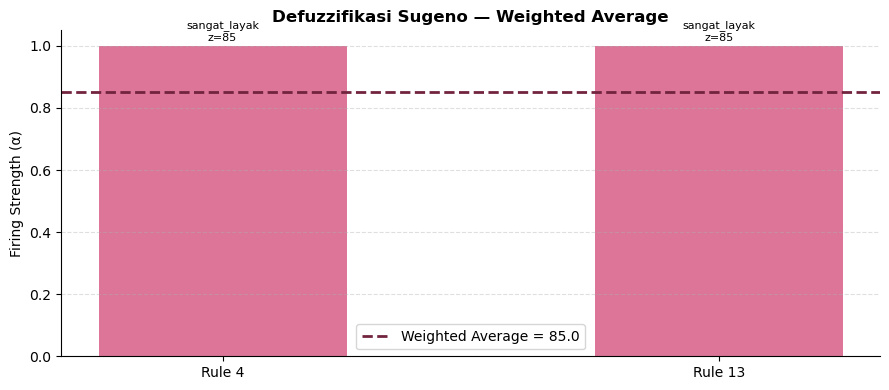

In [25]:
# visualisasi weighted average Sugeno
fired  = result_s['fired_rules']
labels = [r['output'] for r in fired]
alphas = [r['firing_strength'] for r in fired]
zvals  = [r['output_value'] for r in fired]

x_pos = range(len(fired))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(x_pos, alphas, color='#D4537E', alpha=0.8, width=0.5)
ax.axhline(result_s['score'] / 100, color='#72243E', linestyle='--', linewidth=2,
           label=f'Weighted Average = {result_s["score"]}')

for bar, lbl, z in zip(bars, labels, zvals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{lbl}\nz={z}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Rule {r["rule_idx"]}' for r in fired])
ax.set_title('Defuzzifikasi Sugeno — Weighted Average', fontweight='bold')
ax.set_ylabel('Firing Strength (α)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Perbandingan Mamdani vs Sugeno

In [26]:
print('Perbandingan hasil pada input yang sama:')
print(f'  Input  : Harga={harga}, Votes={votes}, Price Range={price_range}, Booking={booking}, Delivery={delivery}')
print()
print(f'  Mamdani : score={result_m["score"]}, level={result_m["level"]}, runtime={result_m["runtime"]}s')
print(f'  Sugeno  : score={result_s["score"]}, level={result_s["level"]}, runtime={result_s["runtime"]}s')
print(f'  Selisih : {abs(result_m["score"] - result_s["score"]):.4f}')

Perbandingan hasil pada input yang sama:
  Input  : Harga=500.0, Votes=200.0, Price Range=2, Booking=1, Delivery=1

  Mamdani : score=79.8395, level=SANGAT LAYAK, runtime=0.00052s
  Sugeno  : score=85.0, level=SANGAT LAYAK, runtime=0.00033s
  Selisih : 5.1605


In [27]:
# uji beberapa kombinasi input berbeda
test_cases = [
    (200,   10,  1, 0, 0, 'Murah, sepi'),
    (500,   60,  2, 1, 0, 'Sedang, cukup votes'),
    (800,  200,  3, 1, 1, 'Agak mahal, ramai'),
    (2000, 5000, 4, 1, 1, 'Mahal, sangat ramai'),
]

print(f"{'Kasus':<25} {'Mamdani':>10} {'Sugeno':>10} {'Selisih':>10} {'Level M':>15}")
print('-' * 75)
for h, v, p, b, d, label in test_cases:
    m = mamdani_predict(h, v, p, b, d)
    s = sugeno_predict(h, v, p, b, d)
    print(f'{label:<25} {m["score"]:>10.4f} {s["score"]:>10.4f} '
          f'{abs(m["score"]-s["score"]):>10.4f} {m["level"]:>15}')

Kasus                        Mamdani     Sugeno    Selisih         Level M
---------------------------------------------------------------------------
Murah, sepi                  29.1261    35.0000     5.8739     TIDAK LAYAK
Sedang, cukup votes          50.0000    50.0000     0.0000     CUKUP LAYAK
Agak mahal, ramai            70.8739    67.5000     3.3739    SANGAT LAYAK
Mahal, sangat ramai          70.8739    67.5000     3.3739    SANGAT LAYAK


## 11. Evaluasi — MAE, MSE, RMSE

Ground truth: `Aggregate rating × 20` (konversi ke skala 0–100)

In [28]:
SAMPLE = 2000
print(f'Evaluasi pada {SAMPLE} data sampel acak dari {len(data)} data...')
print()

t0 = time.time()
actual_m, pred_m = mamdani_batch(data, sample_size=SAMPLE)
rt_m_batch = round(time.time() - t0, 2)

t0 = time.time()
actual_s, pred_s = sugeno_batch(data, sample_size=SAMPLE)
rt_s_batch = round(time.time() - t0, 2)

mae_m  = round(float(np.mean(np.abs(actual_m - pred_m))), 4)
mse_m  = round(float(np.mean((actual_m - pred_m)**2)), 4)
rmse_m = round(float(np.sqrt(mse_m)), 4)

mae_s  = round(float(np.mean(np.abs(actual_s - pred_s))), 4)
mse_s  = round(float(np.mean((actual_s - pred_s)**2)), 4)
rmse_s = round(float(np.sqrt(mse_s)), 4)

print(f"{'Metrik':<12} {'Mamdani':>12} {'Sugeno':>12}")
print('-' * 38)
print(f"{'MAE':<12} {mae_m:>12.4f} {mae_s:>12.4f}")
print(f"{'MSE':<12} {mse_m:>12.4f} {mse_s:>12.4f}")
print(f"{'RMSE':<12} {rmse_m:>12.4f} {rmse_s:>12.4f}")
print(f"{'Runtime':<12} {rt_m_batch:>11.2f}s {rt_s_batch:>11.2f}s")

Evaluasi pada 2000 data sampel acak dari 7403 data...

Metrik            Mamdani       Sugeno
--------------------------------------
MAE               26.3911      24.9131
MSE              952.8040     852.4512
RMSE              30.8675      29.1968
Runtime             1.30s        1.05s


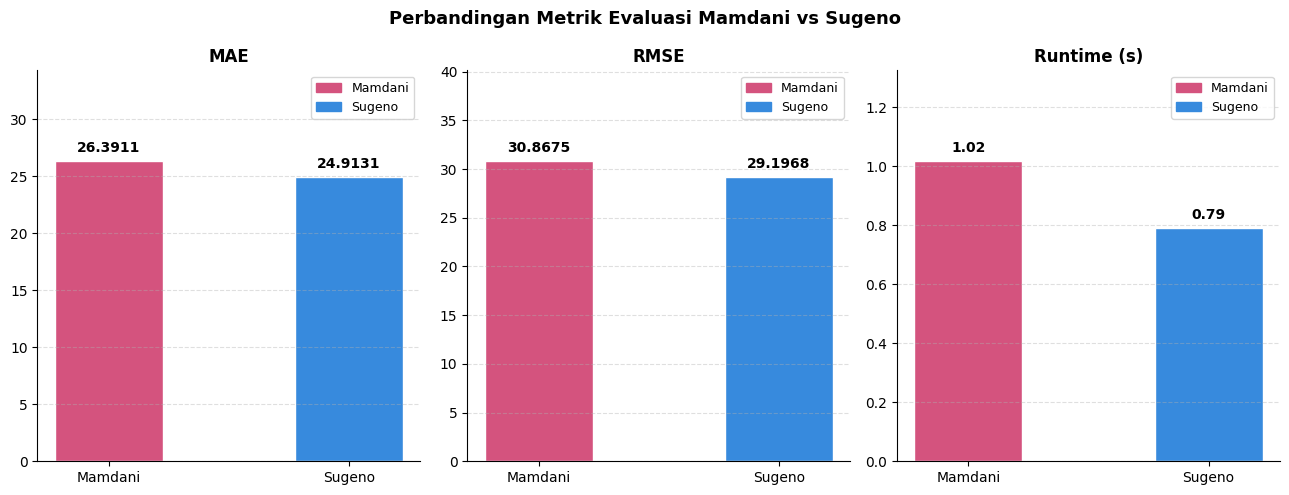

In [23]:
# visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Mamdani vs Sugeno', fontsize=13, fontweight='bold')

metrics_vis = [('MAE', mae_m, mae_s), ('RMSE', rmse_m, rmse_s), ('Runtime (s)', rt_m_batch, rt_s_batch)]

for ax, (title, vm, vs) in zip(axes, metrics_vis):
    bars = ax.bar(['Mamdani', 'Sugeno'], [vm, vs],
                  color=['#D4537E', '#378ADD'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, [vm, vs]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vm, vs)*0.02,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vm, vs) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='#D4537E', label='Mamdani'),
        plt.Rectangle((0,0),1,1, color='#378ADD', label='Sugeno')
    ], fontsize=9)

plt.tight_layout()
plt.show()

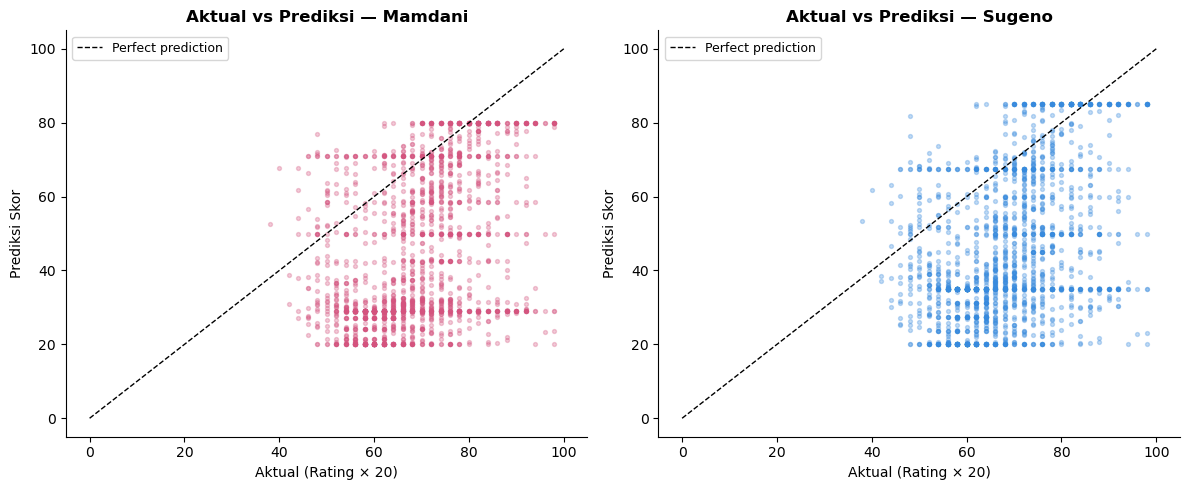

In [30]:
# scatter plot aktual vs prediksi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, actual, pred, label, clr in [
    (axes[0], actual_m, pred_m, 'Mamdani', '#D4537E'),
    (axes[1], actual_s, pred_s, 'Sugeno',  '#378ADD'),
]:
    ax.scatter(actual, pred, alpha=0.3, s=8, color=clr)
    ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Aktual (Rating × 20)')
    ax.set_ylabel('Prediksi Skor')
    ax.set_title(f'Aktual vs Prediksi — {label}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 12. Integrasi Fuzzy

**Arsitektur:** Output fuzzy (Mamdani & Sugeno) dijadikan fitur tambahan untuk Random Forest.  
Fuzzy tidak digantikan ML — output fuzzy menjadi informasi tambahan yang memperkaya fitur.

In [32]:
from ml.random_forest import generate_fuzzy_features, train_and_evaluate

print('Generating fuzzy features...')
df_fuzz = generate_fuzzy_features(data, sample_size=2000)
print(f'Selesai. Shape: {df_fuzz.shape}')
df_fuzz[['Restaurant Name', 'Aggregate rating', 'fuzzy_mamdani', 'fuzzy_sugeno']].head(10)

Generating fuzzy features...
Selesai. Shape: (2000, 9)


,Restaurant Name,Aggregate rating,fuzzy_mamdani,fuzzy_sugeno
4366,Amit Hotel,2.9,29.1261,35.0000
3197,Movenpick,3.9,27.5674,25.6136
4367,Angrezee Dhaba,2.8,61.0230,60.7143
5014,Sagar Ratna,2.3,56.7371,50.2238
554,Fishpatrick's Crabby Cafe,3.2,29.1261,35.0000
6240,Meghraj Food Court,3.0,30.0370,35.9744
4693,Hot Spot,3.8,79.8395,85.0000
3770,Pradhan Ji Multi Cuisine Restaurant,3.3,32.6806,30.4940
6045,United Punjab,2.5,46.8401,45.3605
263,Burnt Toast Cafe,3.4,31.4643,38.0886


In [33]:
print('Training Random Forest...')
results = train_and_evaluate(df_fuzz)

print()
print(f"{'Model':<25} {'MAE':>8} {'MSE':>8} {'RMSE':>8} {'Runtime':>10}")
print('-' * 65)
for tag in ['rf_raw', 'rf_fuzzy']:
    r = results[tag]
    print(f"{r['label']:<25} {r['mae']:>8.4f} {r['mse']:>8.4f} {r['rmse']:>8.4f} {r['runtime']:>9.3f}s")

Training Random Forest...

Model                          MAE      MSE     RMSE    Runtime
-----------------------------------------------------------------
RF tanpa Fuzzy              0.3243   0.1959   0.4426     1.294s
RF + Fuzzy Features         0.3192   0.1929   0.4392     1.759s


In [ ]:
# visualisasi perbandingan RF
labels_rf = [results['rf_raw']['label'], results['rf_fuzzy']['label']]
mae_vals   = [results['rf_raw']['mae'],   results['rf_fuzzy']['mae']]
rmse_vals  = [results['rf_raw']['rmse'],  results['rf_fuzzy']['rmse']]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Perbandingan RF tanpa Fuzzy vs RF + Fuzzy Features', fontsize=12, fontweight='bold')

for ax, title, vals in [(axes[0],'MAE',mae_vals),(axes[1],'RMSE',rmse_vals)]:
    bars = ax.bar(labels_rf, vals, color=['#888888','#D4537E'], width=0.45, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 13. Kesimpulan

In [34]:
print('=' * 60)
print('KESIMPULAN')
print('=' * 60)
print()
print('Perbandingan Mamdani vs Sugeno:')
print(f'  MAE            - Mamdani: {mae_m:.4f} | Sugeno: {mae_s:.4f}')
print(f'  MSE            - Mamdani: {mse_m:.4f} | Sugeno: {mse_s:.4f}')
print(f'  RMSE           - Mamdani: {rmse_m:.4f} | Sugeno: {rmse_s:.4f}')
print(f'  Runtime batch  - Mamdani: {rt_m_batch}s   | Sugeno: {rt_s_batch}s')
print()
print('Interpretasi:')
winner_acc = 'Mamdani' if mae_m <= mae_s else 'Sugeno'
winner_spd = 'Sugeno'  if rt_s_batch <= rt_m_batch else 'Mamdani'
speedup    = round(rt_m_batch / rt_s_batch, 1) if rt_s_batch > 0 else '-'
print(f'  - {winner_acc} menghasilkan akurasi lebih tinggi (MAE lebih rendah)')
print(f'  - {winner_spd} {speedup}x lebih cepat dari metode lainnya')
print()
print('Terdapat trade-off antara akurasi dan kecepatan komputasi.')
print('Untuk sistem rekomendasi restoran yang mengutamakan presisi,')
print('Mamdani lebih direkomendasikan.')

KESIMPULAN

Perbandingan Mamdani vs Sugeno:
  MAE            - Mamdani: 26.3911 | Sugeno: 24.9131
  MSE            - Mamdani: 952.8040 | Sugeno: 852.4512
  RMSE           - Mamdani: 30.8675 | Sugeno: 29.1968
  Runtime batch  - Mamdani: 1.3s   | Sugeno: 1.05s

Interpretasi:
  - Sugeno menghasilkan akurasi lebih tinggi (MAE lebih rendah)
  - Sugeno 1.2x lebih cepat dari metode lainnya

Terdapat trade-off antara akurasi dan kecepatan komputasi.
Untuk sistem rekomendasi restoran yang mengutamakan presisi,
Mamdani lebih direkomendasikan.
